In [16]:
def get_H_CLHE(img, prag):
    h, _ = np.histogram(img, 256, (0, 1.0000001))
    h = h / np.sum(h)  

    exces_total = np.sum(h[h > prag] - prag)  
    redistribuire = exces_total / 256    
    h = np.clip(h, 0, prag)  
    h += redistribuire 
    H = np.cumsum(h)  

    return H

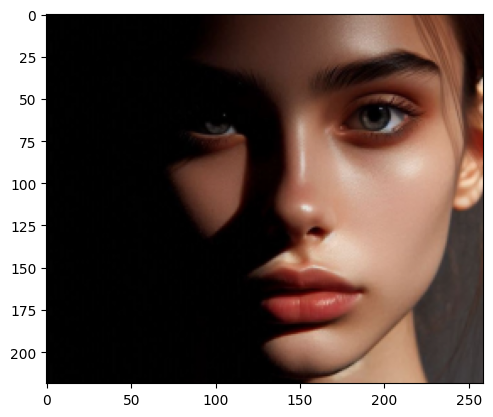

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


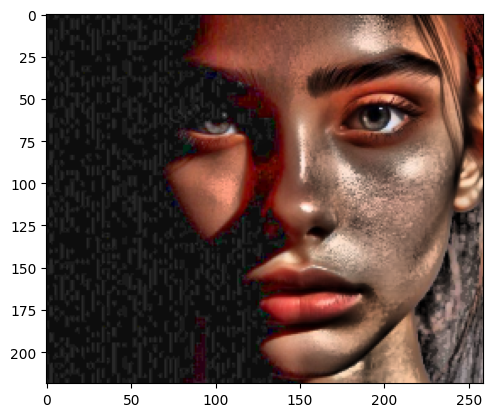

(<Figure size 640x480 with 1 Axes>,
 <function matplotlib.pyplot.colorbar(mappable: 'ScalarMappable | None' = None, cax: 'matplotlib.axes.Axes | None' = None, ax: 'matplotlib.axes.Axes | Iterable[matplotlib.axes.Axes] | None' = None, **kwargs) -> 'Colorbar'>,
 None)

In [17]:
import numpy as np
from skimage import io, color
import matplotlib.pyplot as plt
from scipy import signal

img = io.imread('uneven-face-mic.png')
img = img[:,:,0:3] # luyajm doar planurile rgb fara planul de transparenta
plt.figure(), plt.imshow(img), plt.colorbar, plt.show()

hsv = color.rgb2hsv(img)
Y = hsv[:,:,2]

# [L, C] = np.shape(Y)
# 
# W = 15
# kernel = np.zeros((2*W+1, 2*W+1))
# kernel[W, W] = 1
# Ybordat = signal.convolve2d(Y, kernel, mode='full', boundary='symm')
# 
# Yout = np.zeros((L, C))
# for l in range(L):
#     for c in range(C):
#         ROI = Ybordat[l:l+2*W+1, c:c+2*W+1]  
#         H = get_H_CLHE(ROI, 0.05)
#         Yout[l, c] = H[np.uint8(255 * Y[l, c])]
        
hsv[:,:, 2] = Yout
imgnou = color.hsv2rgb(hsv)

plt.figure(), plt.imshow(imgnou), plt.colorbar, plt.show()

In [18]:
def CLAHE(Y, prag, W):
    [L, C] = np.shape(Y)
    kernel = np.zeros((2*W+1, 2*W+1))
    kernel[W, W] = 1
    Ybordat = signal.convolve2d(Y, kernel, mode='full', boundary='symm')
    
    Yout = np.zeros((L, C))
    for l in range(L):
        for c in range(C):
            ROI = Ybordat[l:l+2*W+1, c:c+2*W+1]  
            H = get_H_CLHE(ROI, prag)
            Yout[l, c] = H[np.uint8(255 * Y[l, c])]
            
    return Yout


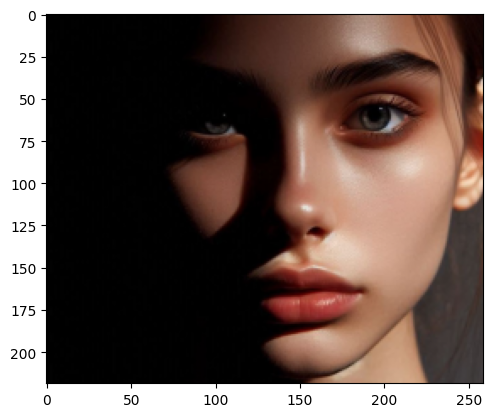

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


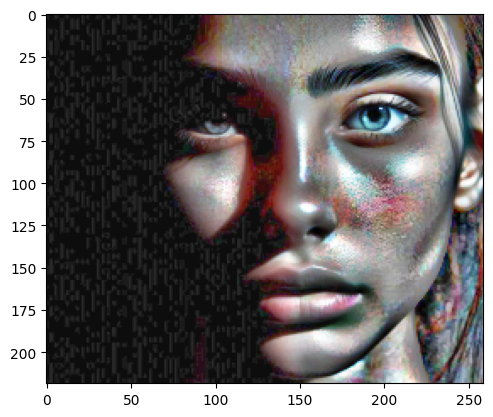

(<Figure size 640x480 with 1 Axes>,
 <function matplotlib.pyplot.colorbar(mappable: 'ScalarMappable | None' = None, cax: 'matplotlib.axes.Axes | None' = None, ax: 'matplotlib.axes.Axes | Iterable[matplotlib.axes.Axes] | None' = None, **kwargs) -> 'Colorbar'>,
 None)

In [19]:
img = io.imread('uneven-face-mic.png')
img = img[:,:,0:3] / 255.0
plt.figure(), plt.imshow(img), plt.colorbar, plt.show()

Rnou = CLAHE(img[:,:,0], 0.05, 15)
Gnou = CLAHE(img[:,:,1], 0.05, 15)
Bnou = CLAHE(img[:,:,2], 0.05, 15)

imgout = np.zeros(np.shape(img))
imgout[:,:,0] = Rnou
imgout[:,:,1] = Gnou
imgout[:,:,2] = Bnou

plt.figure(), plt.imshow(imgout), plt.colorbar, plt.show()



In [33]:
def PHE(Y):
    [Linii, Coloane] = np.shape(Y)
    Y1 = signal.convolve2d(Y, np.ones([3,3])/9, mode='same', boundary='symm') # calculam media aritmetica intr-o vecinatate de 3x3
    Y2 = signal.convolve2d(Y, np.ones([5,5])/25, mode='same', boundary='symm')
    Y3 = signal.convolve2d(Y, np.ones([7,7])/49, mode='same', boundary='symm')
    # media aritmetica este echivalenta cu convolutia bidimensionala -> ce am facut ca sa o pacalim sa ne faca bordarea? 
    
    L1 = np.ndarray.flatten(Y) # transformam imaginea intr-un vector linie.
    L1 = L1.T
    L2 = np.ndarray.flatten(Y1)
    L2 = L2.T
    L3 = np.ndarray.flatten(Y2)
    L3 = L3.T
    L4 = np.ndarray.flatten(Y3)
    L4 = L4.T
    
    indici = np.lexsort((L4,L3,L2,L1))
    Q = Linii * Coloane // 256
    
    OUT = 255*np.ones([Linii * Coloane])
    for i in range(0, 256):
        for j in range(i * Q, i * Q + Q):
            OUT[indici[j]]=i # vector linie
    
    IMGOUT = np.reshape(OUT, (Linii, Coloane))  # ca sa nu mai fie vector linie
    
    return IMGOUT

def specificare(Y, h):
    [Linii, Coloane]=np.shape(Y)
    h = h/np.sum(h)
    h = np.uintc((Linii*Coloane)*h)
    hcum = np.cumsum(h)
    Hcum = np.zeros([257])
    Hcum[1:]=hcum

    Y1 = signal.convolve2d(Y, np.ones([3,3])/9, mode='same', boundary='symm')
    Y2 = signal.convolve2d(Y, np.ones([5,5])/25, mode='same', boundary='symm')
    Y3 = signal.convolve2d(Y, np.ones([7,7])/49, mode='same', boundary='symm')

    L1 = np.ndarray.flatten(Y)
    L1 = L1.T
    L2 = np.ndarray.flatten(Y1)
    L2 = L2.T
    L3 = np.ndarray.flatten(Y2)
    L3 = L3.T
    L4 = np.ndarray.flatten(Y3)
    L4 = L4.T

    indici = np.lexsort((L4,L3,L2,L1))

    #Q = Linii*Coloane//256 : aici va fi h[i]

    OUT = 255*np.ones([Linii*Coloane])
    for i in range(0,256):
        for j in range(hcum[i-1],hcum[i]):
            OUT[indici[j]]=i

    IMGOUT = np.reshape(OUT,(Linii,Coloane))

    return IMGOUT

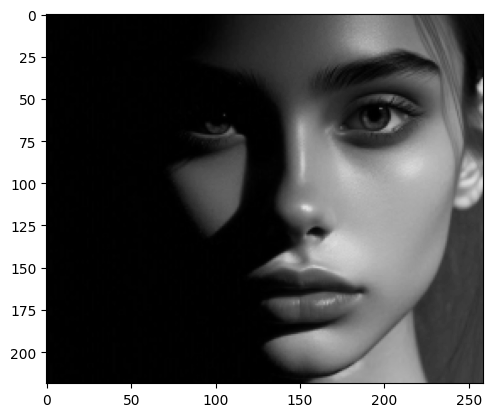

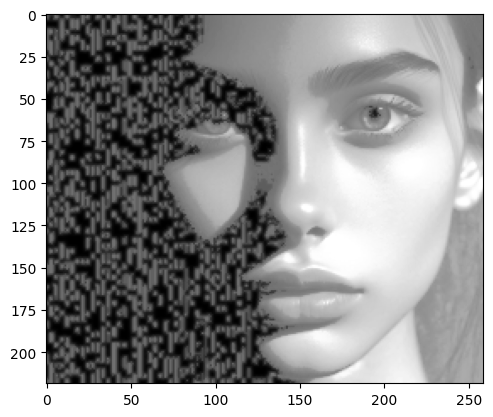

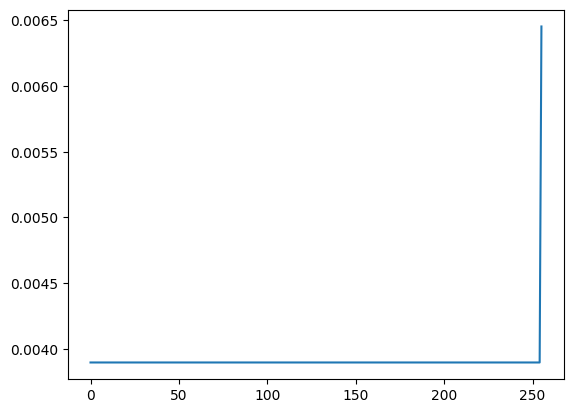

(<Figure size 640x480 with 1 Axes>,
 None)

In [23]:
img = io.imread('uneven-face-mic.png')
img = img[:,:,0:3]
Y = color.rgb2gray(img)
plt.figure(), plt.imshow(Y, cmap='gray', vmin = 0, vmax=1), plt.colorbar, plt.show()

# egalizare perfecta
Ynou = PHE(np.uint8(255*Y))
plt.figure(), plt.imshow(Ynou, cmap='gray', vmin = 0, vmax=255), plt.colorbar, plt.show()

# histograma plata, intinsa peste tot
hnou, _ = np.histogram(Ynou, 256, (0, 256))
# normalizam:
hnou = hnou / np.sum(hnou)

plt.figure(), plt.plot(hnou), plt.show()


In [26]:
print(np.min(Ynou))
print(np.max(Ynou))

print(hnou)
print(np.prod(np.shape(Ynou)) / 256)
print(221/np.prod(np.shape(Ynou)))

0.0
255.0
[0.00389626 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626
 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626
 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626
 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626
 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626
 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626
 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626
 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626
 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626
 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626
 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626
 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626
 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626
 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626 0.00389626
 0.00389626 0.00389626 0.00389626 0.00389626 0.00389

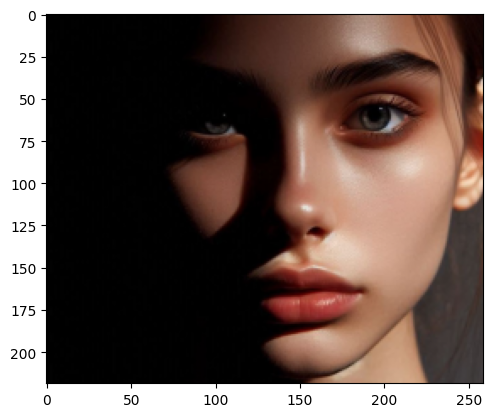

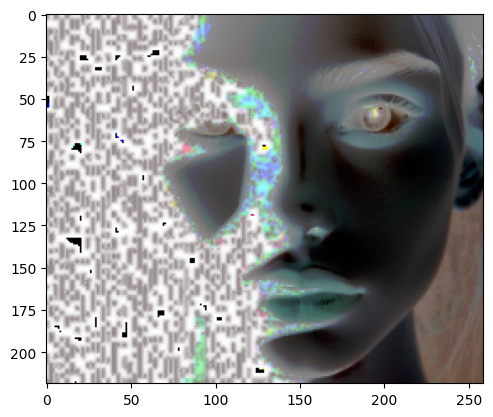

(<Figure size 640x480 with 1 Axes>,
 <function matplotlib.pyplot.colorbar(mappable: 'ScalarMappable | None' = None, cax: 'matplotlib.axes.Axes | None' = None, ax: 'matplotlib.axes.Axes | Iterable[matplotlib.axes.Axes] | None' = None, **kwargs) -> 'Colorbar'>,
 None)

In [30]:
img = io.imread('uneven-face-mic.png')
img = img[:,:,0:3] / 255.0
plt.figure(), plt.imshow(img), plt.colorbar, plt.show()

Rnou = PHE(img[:,:,0])
Gnou = PHE(img[:,:,1])
Bnou = PHE(img[:,:,2])

imgout = np.zeros(np.shape(img))
imgout[:,:,0] = Rnou
imgout[:,:,1] = Gnou
imgout[:,:,2] = Bnou

plt.figure(), plt.imshow(np.uint8(255* imgout)), plt.colorbar, plt.show()


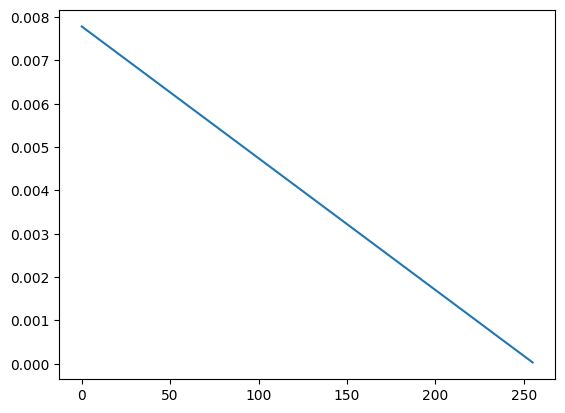

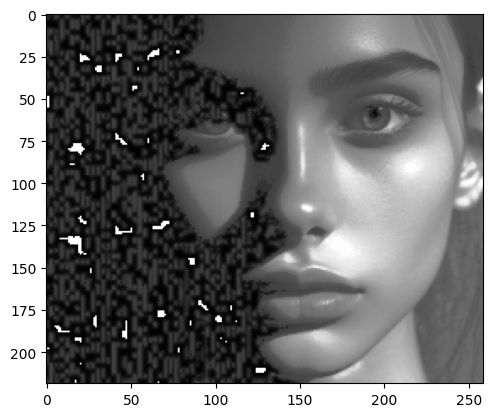

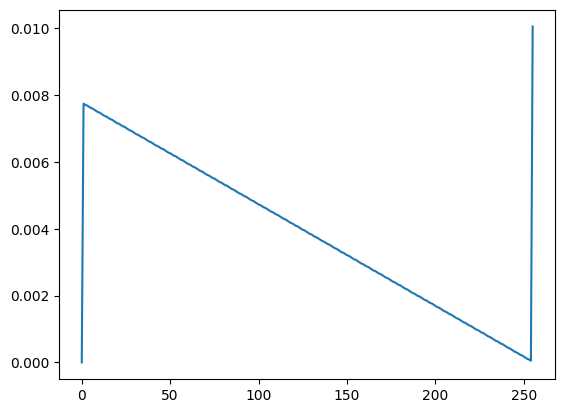

(<Figure size 640x480 with 1 Axes>,
 None)

In [35]:
hspec = np.zeros(256)
for i in range(0, 256):
    # hspec[i]=i
    hspec[i] = 256 - i

hspec = hspec / np.sum(hspec)

plt.figure(), plt.plot(hspec), plt.show()

Ynou = specificare(np.uint8(255 * Y), hspec)
plt.figure(), plt.imshow(Ynou, cmap='gray', vmin=0, vmax=255), plt.colorbar, plt.show()

hnou, _ = np.histogram(Ynou, 256, (0, 256))  # histograma plata, intinsa peste tot
hnou = hnou / np.sum(hnou)  # normalizam
plt.figure(), plt.plot(hnou), plt.show()




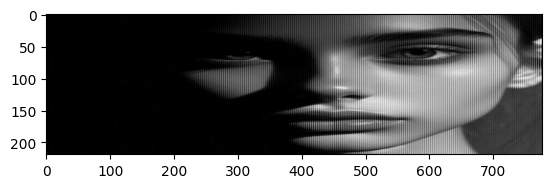

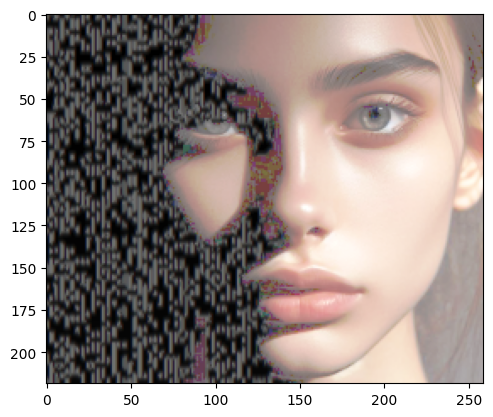

(<Figure size 640x480 with 1 Axes>,
 None)

In [39]:
# AHE
img = io.imread('uneven-face-mic.png')
img = img[:, :, 0:3]
[L, C, pl] = np.shape(img)

I = np.zeros((L, 3 * C))
for c in range(C):
    I[:, 3 * c] = img[:, c, 0]
    I[:, 3 * c + 1] = img[:, c, 1]
    I[:, 3 * c + 2] = img[:, c, 2]

plt.figure(), plt.imshow(I, cmap='gray'), plt.show()

Inou = PHE(I)
imgnou = np.zeros(np.shape(img))
for c in range(C):
    imgnou[:, c, 0] = Inou[:, 3 * c]
    imgnou[:, c, 1] = Inou[:, 3 * c + 1]
    imgnou[:, c, 2] = Inou[:, 3 * c + 2]
    
plt.figure(), plt.imshow(np.uint8(imgnou)), plt.show()
    